In [1]:
# Завантажуємо файл напряму з GitHub
!curl -L -o process_bank_churn.py https://raw.githubusercontent.com/yuliaforostiana/machine_learning_works/refs/heads/main/supervised_learning/process_bank_churn.py

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed

  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100  6604  100  6604    0     0  15684      0 --:--:-- --:--:-- --:--:-- 15761


# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from process_bank_churn import preprocess_data, preprocess_new_data
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import f1_score, roc_curve, auc, confusion_matrix

**Functions for automation**

In [3]:
def classify_analysis(targets, inputs, model, name = ''):

    pred = model.predict(inputs)
    pred_proba = model.predict_proba(inputs)[:,1]
    pred_class = (pred_proba >= 0.5).astype(int)


    f1_score_value = f1_score(targets, pred_class, pos_label = True)
    print(f'F1 score on {name}: {round(f1_score_value, 4)}')


    cf = confusion_matrix(targets, pred_class, normalize = 'true')
    plt.figure()
    sns.heatmap(cf, annot = True)
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))


    fpr, tpr, thresholds = roc_curve(targets, pred_proba, pos_label = True)

    roc_auc = auc(fpr, tpr)
    print(f'AUROC for {name}: {round(roc_auc, 4)}')


    plt.figure()
    plt.plot(fpr, tpr, color = 'darkorange', lw =2, label = f'ROC curve (area = {round(roc_auc, 2)})')
    plt.plot([0, 1], [0, 1], color = 'navy', lw = 2, linestyle = '--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC for {name}')
    plt.legend(loc = "lower right")
    plt.show()


In [4]:
def importance_features(X_train, model, n=10):
    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    }).sort_values('importance', ascending = False).round(4)

    print(f"TOP-{n} найважливіших ознак")
    display(importance_df.head(n))

    plt.title('Feature Importance')
    sns.barplot(data = importance_df.head(10), x = 'importance', y = 'feature');

**Data loading and processing**

In [5]:
raw_df = pd.read_csv('train.csv')

In [6]:
raw_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [7]:
target_col = 'Exited'
inputs_cols = ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
map_cols = ['Gender']
encoder_cols = ['Geography']
map_codes = {'Female': 1, 'Male': 0}

In [8]:
preprocess_df = preprocess_data(raw_df, target_col, inputs_cols, map_cols, map_codes, encoder_cols, scaler_numeric=True)

In [9]:
X_train = preprocess_df['X_train']
X_val = preprocess_df['X_val']
train_targets = preprocess_df['y_train']
val_targets = preprocess_df['y_val']
scaler = preprocess_df['scaler']
encoder = preprocess_df['encoder']

In [10]:
print("Дизайн матриця навчального набору")
display(X_train.head())

print("Цільова метрика навчального набору")
display(train_targets.head())

Дизайн матриця навчального набору


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
7180,0.320187,-0.944682,-1.447264,1.475464,-1.108193,0.515062,1.016977,0.569450,1.0,0.0,0.0
10393,0.347838,0.161227,-1.087792,2.254434,-1.108193,0.515062,-0.983306,0.603803,1.0,0.0,0.0
80,0.638166,-0.330288,0.350096,1.223831,0.769304,0.515062,-0.983306,1.238026,0.0,1.0,0.0
3365,0.140460,2.495924,-1.806736,-0.717950,0.769304,-1.941514,1.016977,-1.457116,0.0,0.0,1.0
12236,0.665816,-2.050591,-0.728320,-0.717950,0.769304,0.515062,1.016977,0.670629,1.0,0.0,0.0


Цільова метрика навчального набору


7180     0.0
10393    0.0
80       0.0
3365     0.0
12236    0.0
Name: Exited, dtype: float64

# DecisionTreeClassifier

In [11]:
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

F1 score on Training: 1.0
AUROC for Training: 1.0


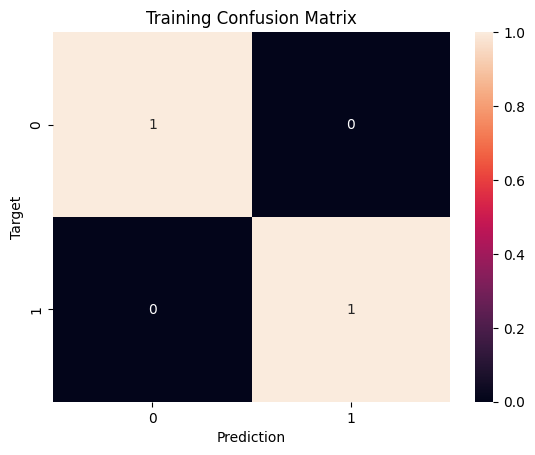

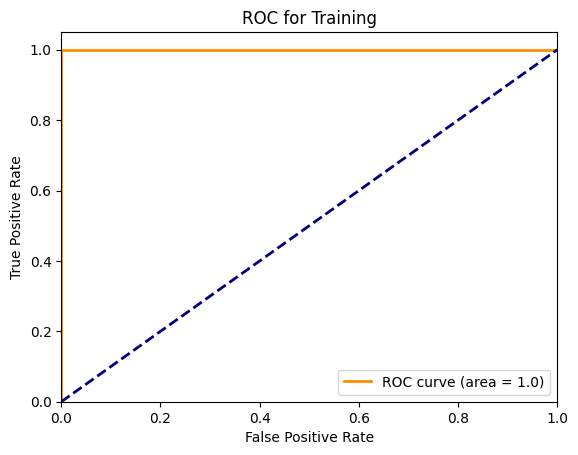

In [12]:
classify_analysis(train_targets, X_train, model, 'Training')

F1 score on Validation: 0.6287
AUROC for Validation: 0.7701


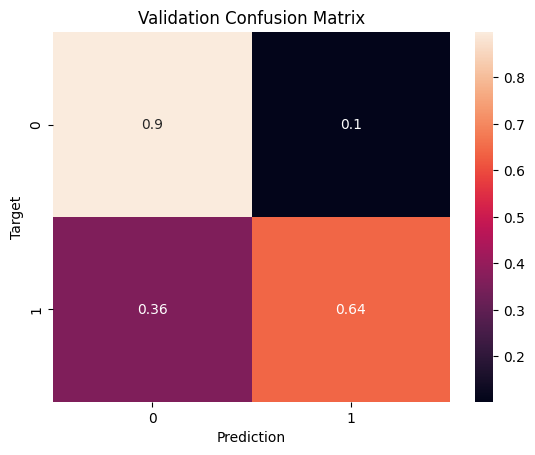

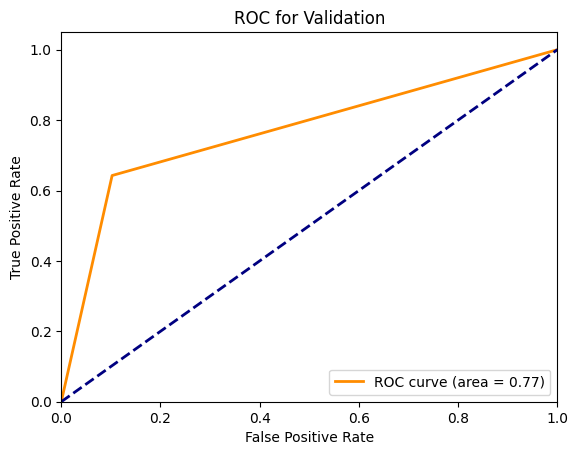

In [13]:
classify_analysis(val_targets, X_val, model, 'Validation')

In [14]:
print("Глибина дерева побудованого на ознаках за замовчування:", model.tree_.max_depth)
print("Кількість вузлів дерева побудованого на ознаках за замовчування:", model.tree_.node_count)

Глибина дерева побудованого на ознаках за замовчування: 24
Кількість вузлів дерева побудованого на ознаках за замовчування: 2723


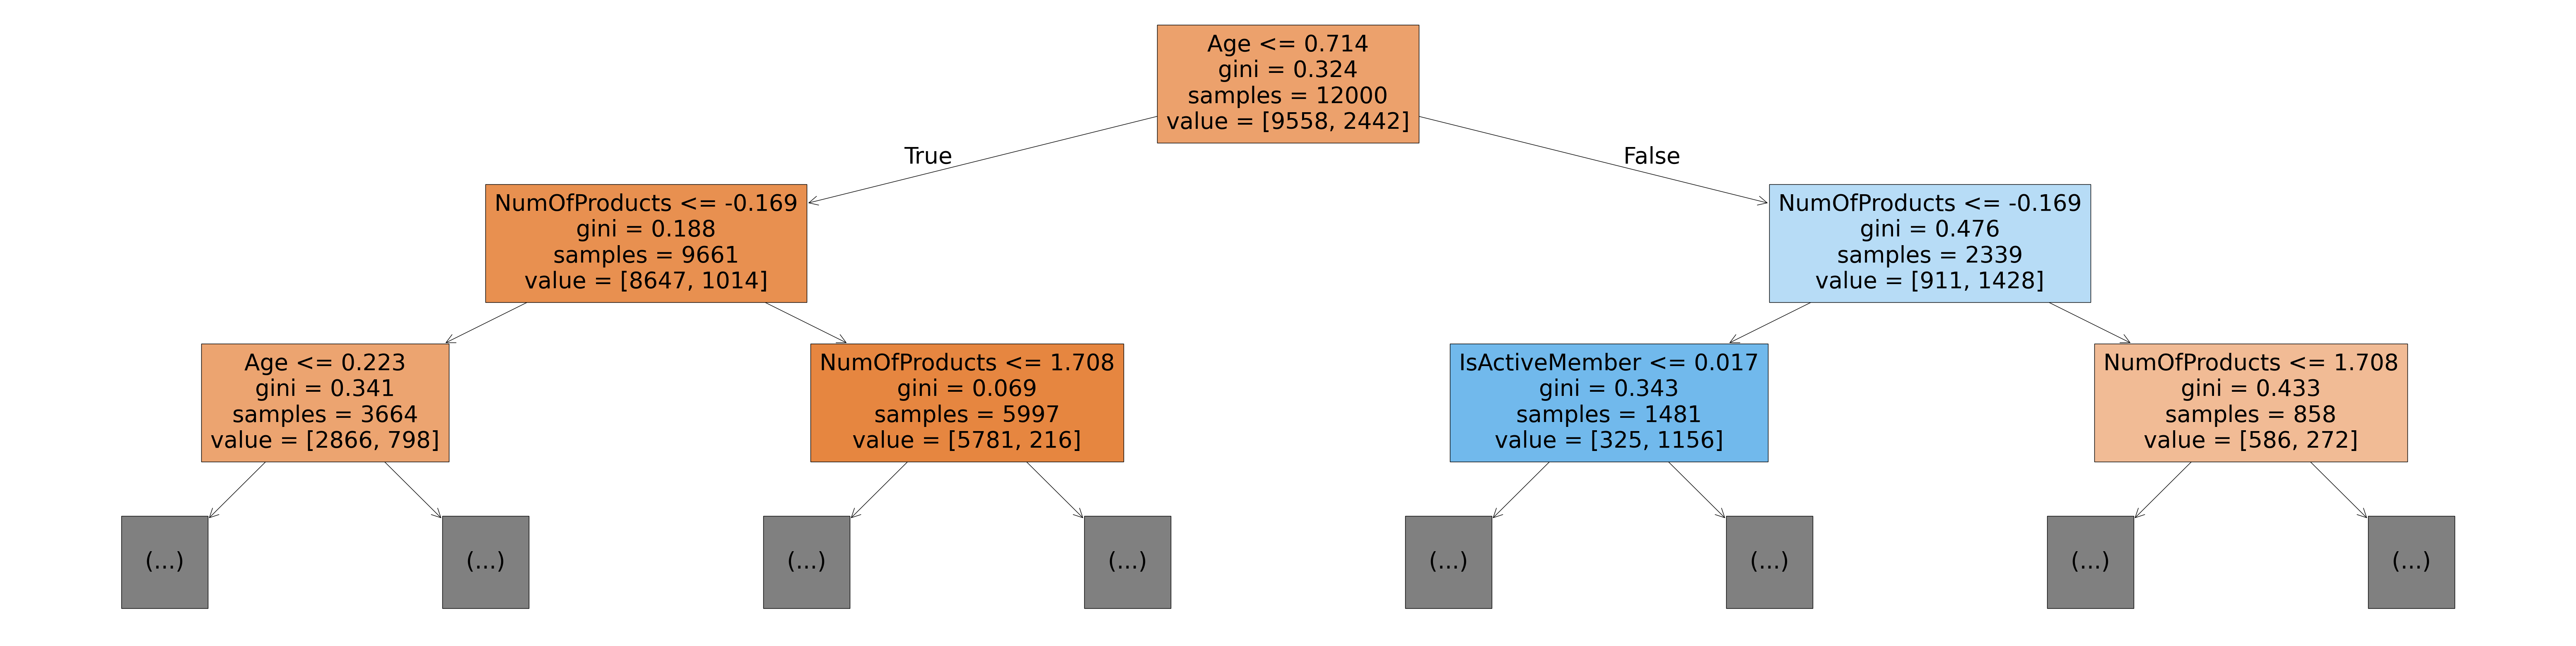

In [15]:
plt.figure(figsize=(80,20))
plot_tree(model, feature_names = X_train.columns, max_depth = 2, filled = True);

In [16]:
tree_text = export_text(model, max_depth=2, feature_names=list(X_train.columns))
print(tree_text[:5000])

|--- Age <= 0.71
|   |--- NumOfProducts <= -0.17
|   |   |--- Age <= 0.22
|   |   |   |--- truncated branch of depth 22
|   |   |--- Age >  0.22
|   |   |   |--- truncated branch of depth 18
|   |--- NumOfProducts >  -0.17
|   |   |--- NumOfProducts <= 1.71
|   |   |   |--- truncated branch of depth 19
|   |   |--- NumOfProducts >  1.71
|   |   |   |--- truncated branch of depth 7
|--- Age >  0.71
|   |--- NumOfProducts <= -0.17
|   |   |--- IsActiveMember <= 0.02
|   |   |   |--- truncated branch of depth 17
|   |   |--- IsActiveMember >  0.02
|   |   |   |--- truncated branch of depth 16
|   |--- NumOfProducts >  -0.17
|   |   |--- NumOfProducts <= 1.71
|   |   |   |--- truncated branch of depth 21
|   |   |--- NumOfProducts >  1.71
|   |   |   |--- class: 1.0



TOP-10 найважливіших ознак


,feature,importance
1,Age,0.3534
4,NumOfProducts,0.1684
0,CreditScore,0.1368
7,EstimatedSalary,0.1262
3,Balance,0.0924
2,Tenure,0.0480
6,IsActiveMember,0.0326
9,Geography_Germany,0.0156
5,HasCrCard,0.0123
8,Geography_France,0.0079


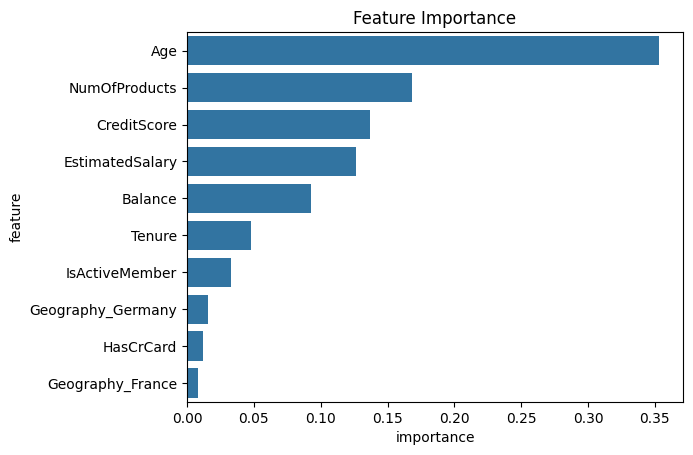

In [17]:
importance_features(X_train, model, n=10)

According to the results of the basic model simulation, there is a clear overtraining, on the training data we have 100% correspondence to the real data, while the area under the ROC curve is 0.77.

Regarding the importance of the factors, according to the tree of depth up to 2 inclusive, we can distinguish Age and NumOfProducts.

At the same time, according to the results of the importance of the factors, we can see that the most important features are Age, NumOfProducts and CreditScore.

In [18]:
model_cust_1 = DecisionTreeClassifier(max_depth = 18, random_state = 42)
model_cust_1.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",18
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [19]:
print("Глибина дерева:", model_cust_1.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_1.tree_.node_count)

Глибина дерева: 18
Кількість вузлів дерева: 2557


F1 score on Training: 0.9854
AUROC for Training: 0.9998


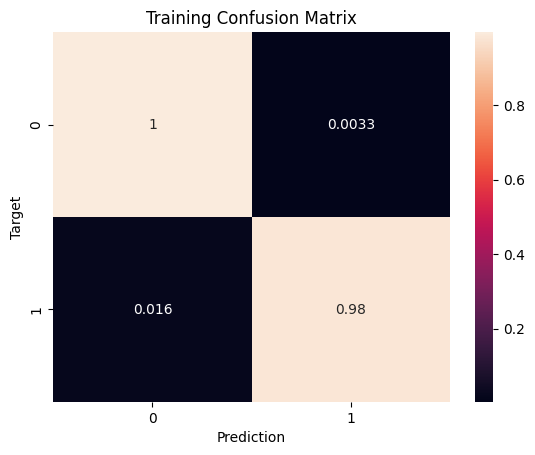

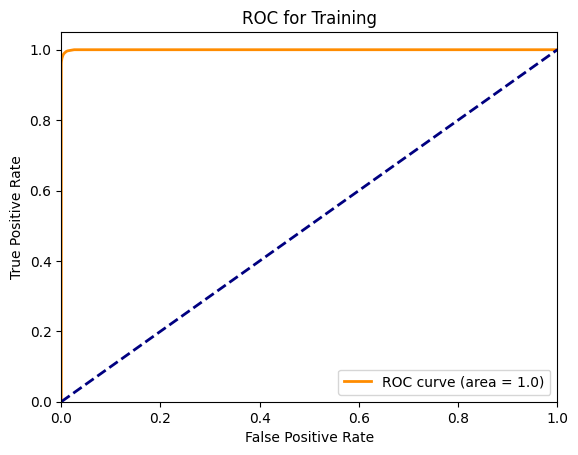

In [20]:
classify_analysis(train_targets, X_train, model_cust_1, 'Training')

F1 score on Validation: 0.6369
AUROC for Validation: 0.7798


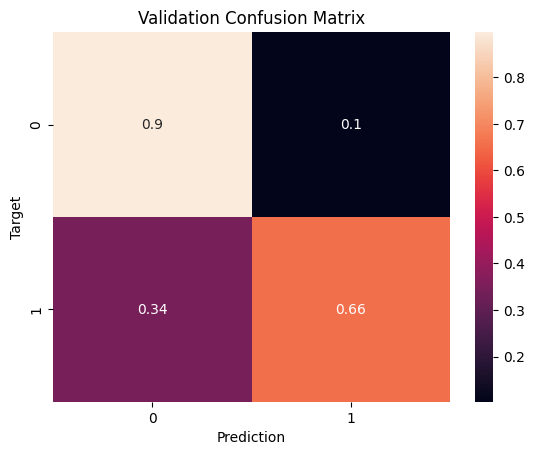

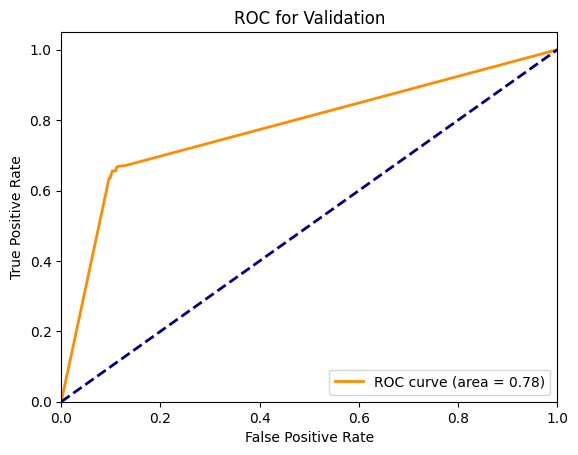

In [21]:
classify_analysis(val_targets, X_val, model_cust_1, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.3621
4,NumOfProducts,0.1727
0,CreditScore,0.1303
7,EstimatedSalary,0.1192
3,Balance,0.0903
2,Tenure,0.0514
6,IsActiveMember,0.0334
9,Geography_Germany,0.0159
5,HasCrCard,0.0122
8,Geography_France,0.0074


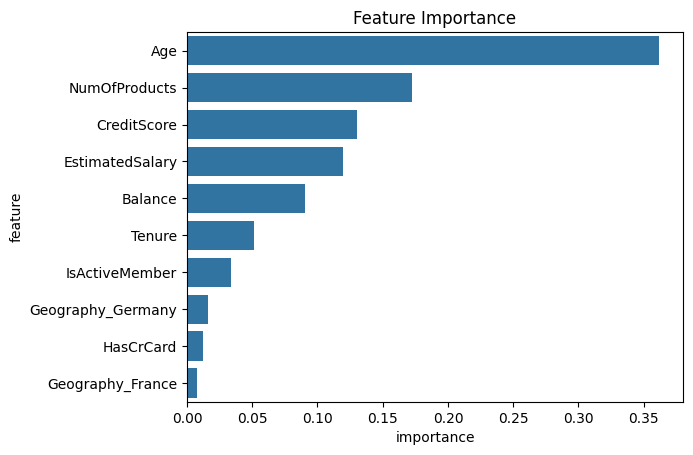

In [22]:
importance_features(X_train, model_cust_1, n=10)

In [23]:
model_cust_2 = DecisionTreeClassifier(max_depth = 7, random_state = 42)
model_cust_2.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [24]:
print("Глибина дерева:", model_cust_2.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_2.tree_.node_count)

Глибина дерева: 7
Кількість вузлів дерева: 199


F1 score on Training: 0.7595
AUROC for Training: 0.9402


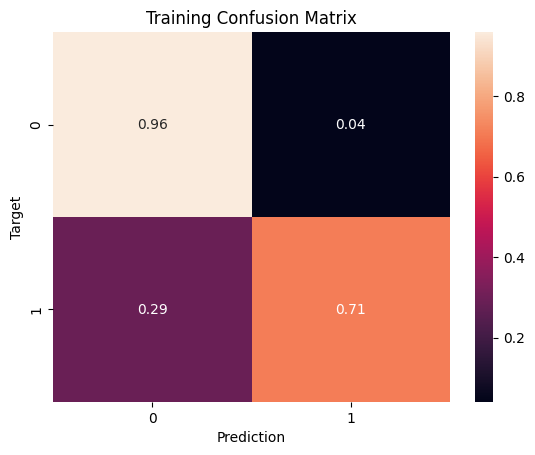

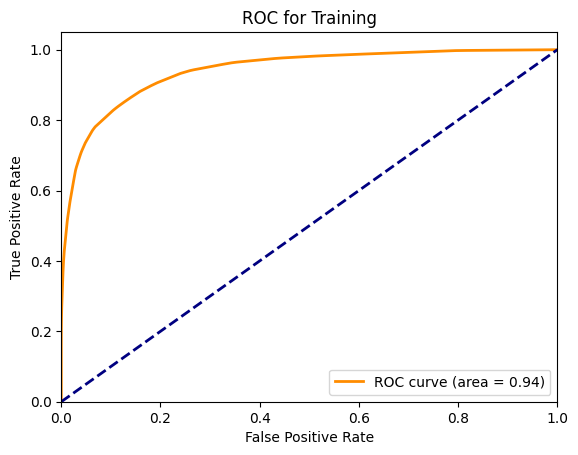

In [25]:
classify_analysis(train_targets, X_train, model_cust_2, 'Training')

F1 score on Validation: 0.7158
AUROC for Validation: 0.9193


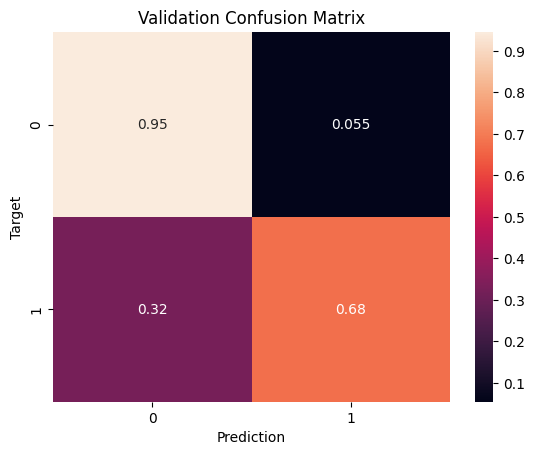

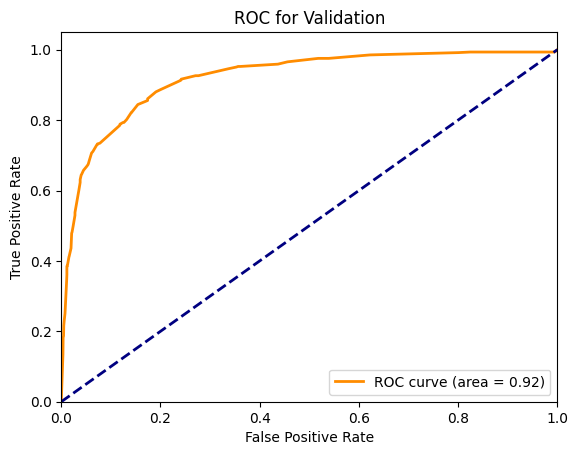

In [26]:
classify_analysis(val_targets, X_val, model_cust_2, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5376
4,NumOfProducts,0.2925
3,Balance,0.0567
6,IsActiveMember,0.0562
9,Geography_Germany,0.0240
0,CreditScore,0.0161
7,EstimatedSalary,0.0099
10,Geography_Spain,0.0031
2,Tenure,0.0029
8,Geography_France,0.0010


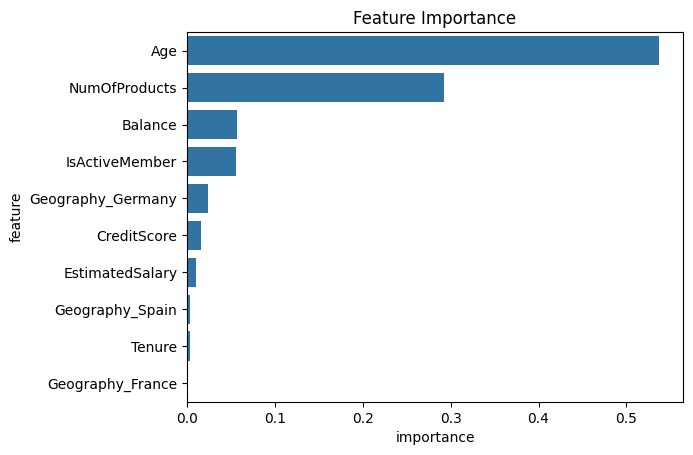

In [27]:
importance_features(X_train, model_cust_2, n=10)

In [28]:
model_cust_3 = DecisionTreeClassifier(max_depth = 30, random_state=42)
model_cust_3.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [29]:
print("Глибина дерева:", model_cust_3.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_3.tree_.node_count)

Глибина дерева: 24
Кількість вузлів дерева: 2723


F1 score on Training: 1.0
AUROC for Training: 1.0


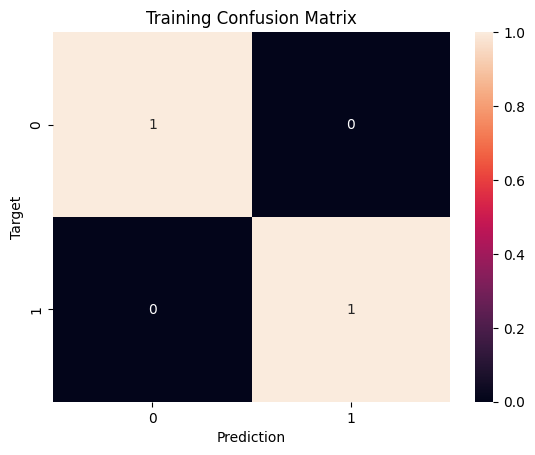

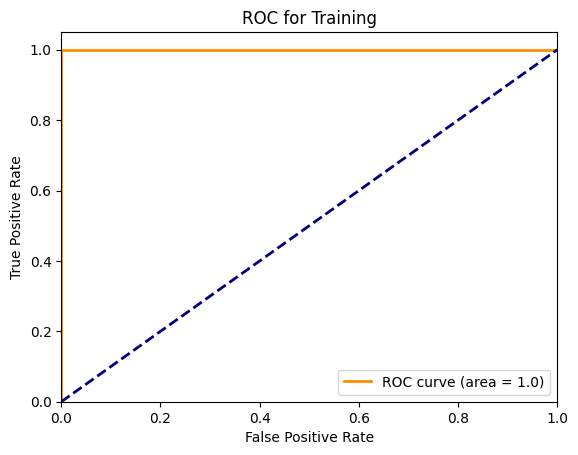

In [30]:
classify_analysis(train_targets, X_train, model_cust_3, 'Training')

F1 score on Validation: 0.6287
AUROC for Validation: 0.7701


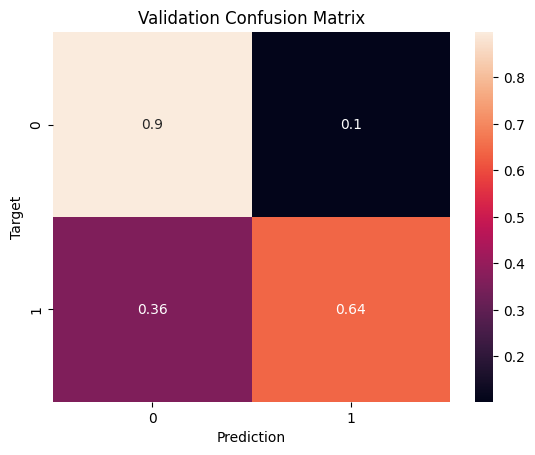

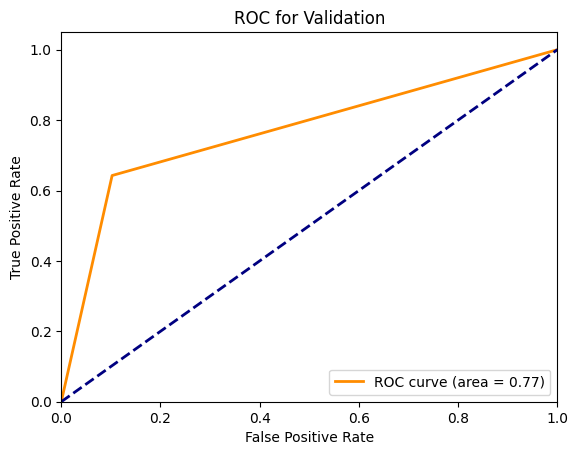

In [31]:
classify_analysis(val_targets, X_val, model_cust_3, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.3534
4,NumOfProducts,0.1684
0,CreditScore,0.1368
7,EstimatedSalary,0.1262
3,Balance,0.0924
2,Tenure,0.0480
6,IsActiveMember,0.0326
9,Geography_Germany,0.0156
5,HasCrCard,0.0123
8,Geography_France,0.0079


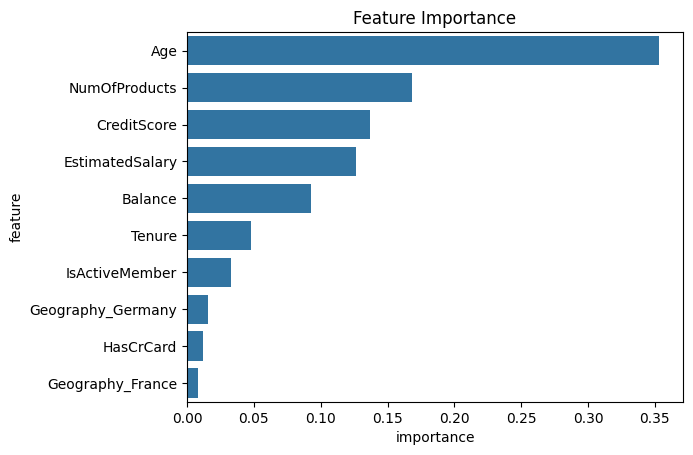

In [32]:
importance_features(X_train, model_cust_3, 10)

In [33]:
model_cust_4 = DecisionTreeClassifier(max_leaf_nodes= 60, random_state=42)
model_cust_4.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",60
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

In [34]:
print("Глибина дерева:", model_cust_4.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_4.tree_.node_count)

Глибина дерева: 10
Кількість вузлів дерева: 119


F1 score on Training: 0.7653
AUROC for Training: 0.9321


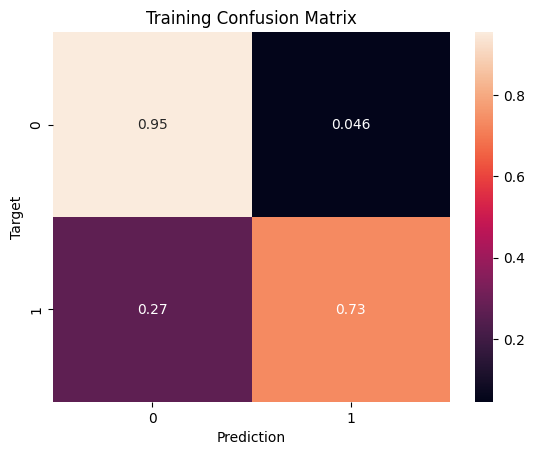

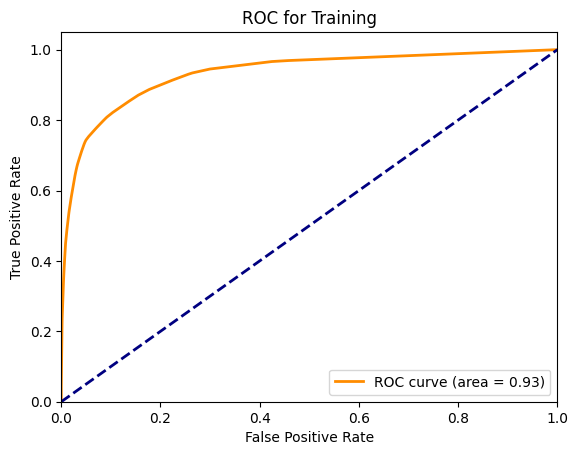

In [35]:
classify_analysis(train_targets, X_train, model_cust_4, 'Training')

F1 score on Validation: 0.7161
AUROC for Validation: 0.9187


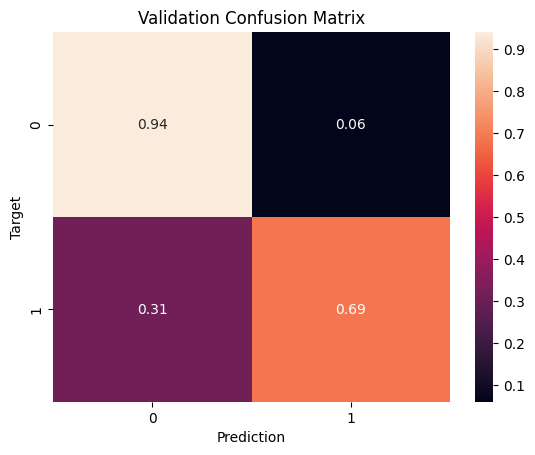

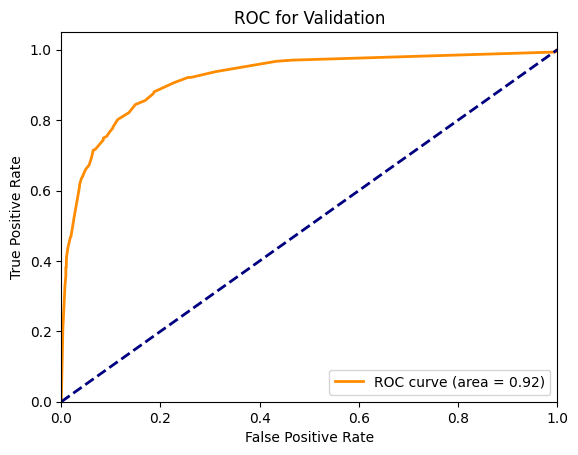

In [36]:
classify_analysis(val_targets, X_val, model_cust_4, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5416
4,NumOfProducts,0.2969
3,Balance,0.0584
6,IsActiveMember,0.0546
9,Geography_Germany,0.0251
0,CreditScore,0.0135
2,Tenure,0.0043
7,EstimatedSalary,0.0038
10,Geography_Spain,0.0019
5,HasCrCard,0.0000


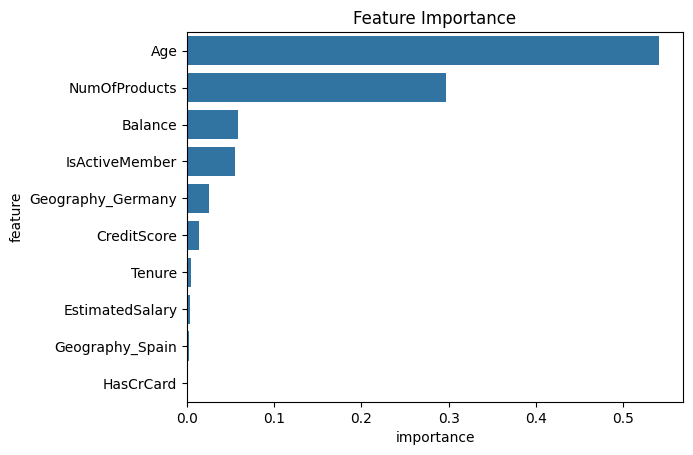

In [37]:
importance_features(X_train, model_cust_4, 10)

In [38]:
model_cust_5 = DecisionTreeClassifier(max_leaf_nodes= 1200, random_state=42)
model_cust_5.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",1200
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [39]:
print("Глибина дерева:", model_cust_5.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_5.tree_.node_count)

Глибина дерева: 24
Кількість вузлів дерева: 2399


F1 score on Training: 0.9869
AUROC for Training: 0.9947


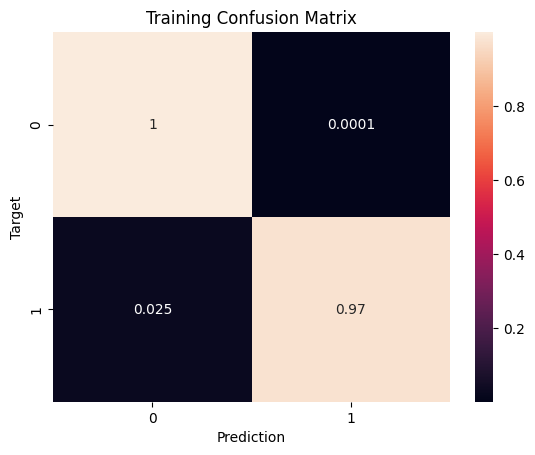

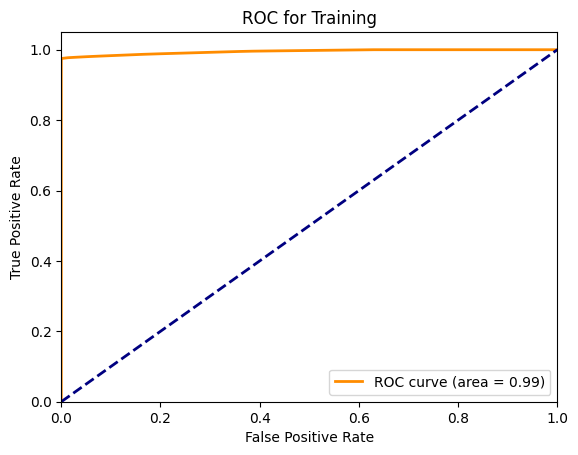

In [40]:
classify_analysis(train_targets, X_train, model_cust_5, 'Training')

F1 score on Validation: 0.6351
AUROC for Validation: 0.6936


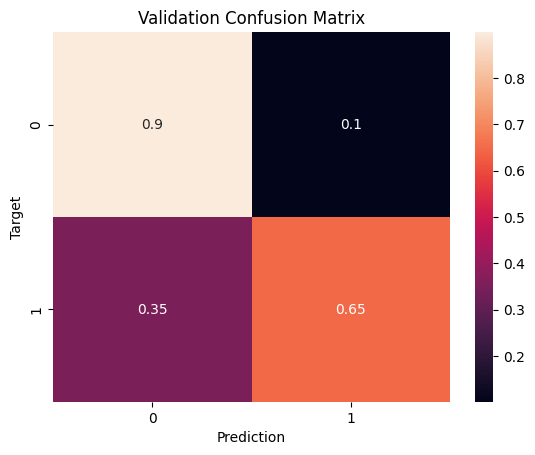

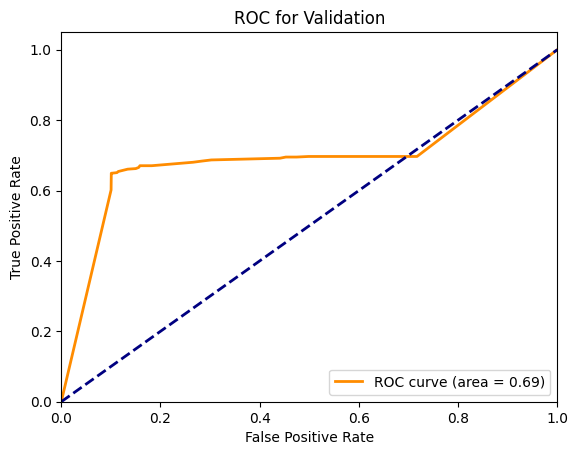

In [41]:
classify_analysis(val_targets, X_val, model_cust_5, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.3629
4,NumOfProducts,0.1739
0,CreditScore,0.1232
7,EstimatedSalary,0.1148
3,Balance,0.0956
2,Tenure,0.0546
6,IsActiveMember,0.0333
9,Geography_Germany,0.0172
5,HasCrCard,0.0117
8,Geography_France,0.0072


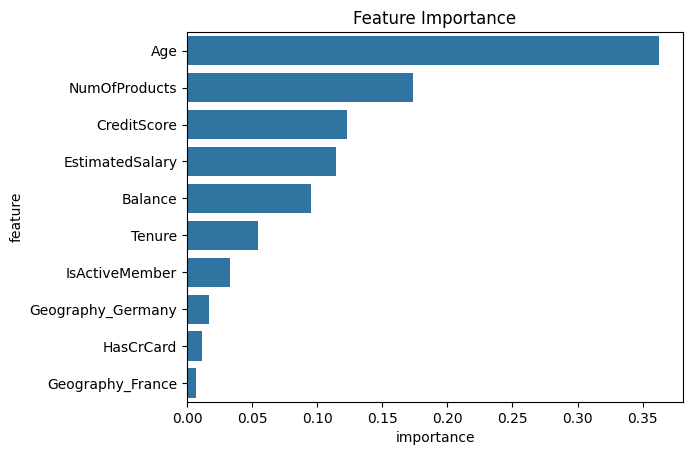

In [42]:
importance_features(X_train, model_cust_5, 10)

In [43]:
model_cust_6 = DecisionTreeClassifier(max_leaf_nodes= 3500, random_state=42)
model_cust_6.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",3500
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [44]:
print("Глибина дерева:", model_cust_5.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_6.tree_.node_count)

Глибина дерева: 24
Кількість вузлів дерева: 2725


F1 score on Training: 1.0
AUROC for Training: 1.0


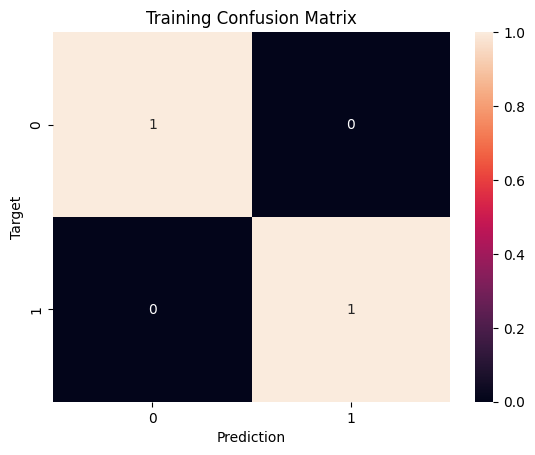

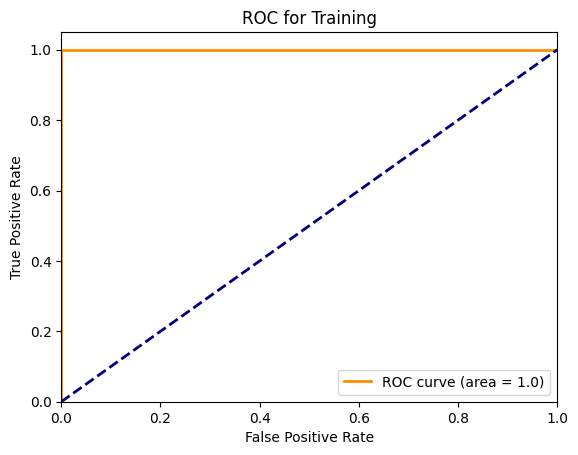

In [45]:
classify_analysis(train_targets, X_train, model_cust_6, 'Training')

F1 score on Validation: 0.6276
AUROC for Validation: 0.771


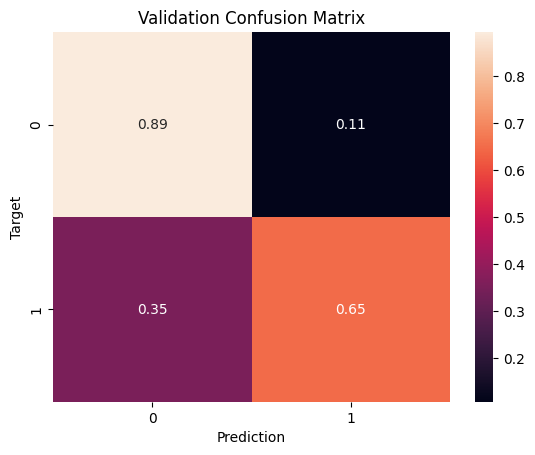

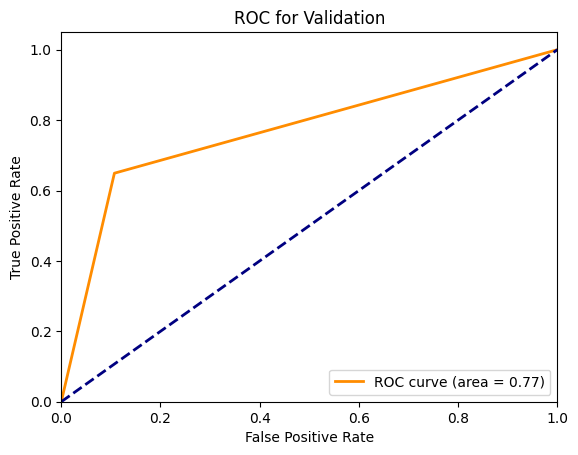

In [46]:
classify_analysis(val_targets, X_val, model_cust_6, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.3545
4,NumOfProducts,0.1684
0,CreditScore,0.1311
7,EstimatedSalary,0.1219
3,Balance,0.0931
2,Tenure,0.0561
6,IsActiveMember,0.0329
9,Geography_Germany,0.0166
5,HasCrCard,0.0117
8,Geography_France,0.0075


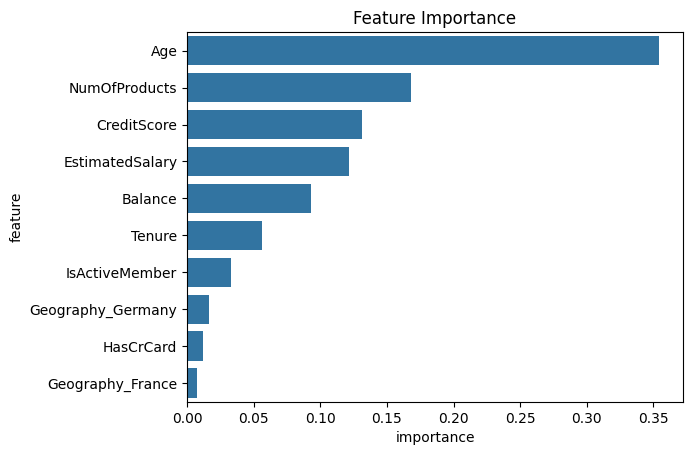

In [47]:
importance_features(X_train, model_cust_6, 10)

In [48]:
model_cust_7 = DecisionTreeClassifier(max_depth = 7, max_leaf_nodes= 25, random_state=42)
model_cust_7.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",25
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node

In [49]:
print("Глибина дерева:", model_cust_7.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_7.tree_.node_count)

Глибина дерева: 7
Кількість вузлів дерева: 49


F1 score on Training: 0.7404
AUROC for Training: 0.9201


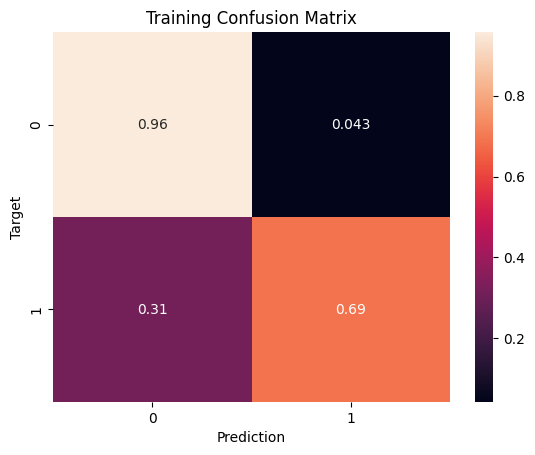

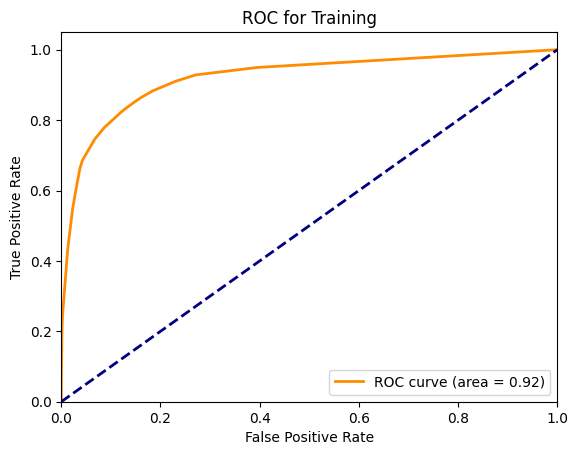

In [50]:
classify_analysis(train_targets, X_train, model_cust_7, 'Training')

F1 score on Validation: 0.7236
AUROC for Validation: 0.9179


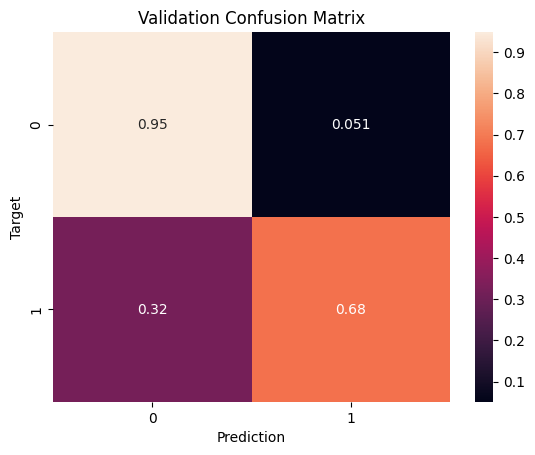

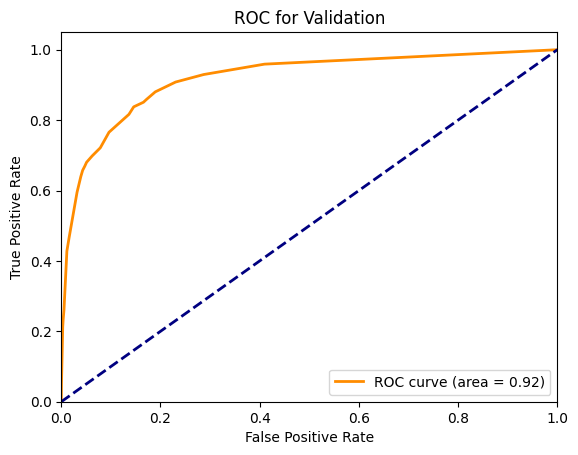

In [51]:
classify_analysis(val_targets, X_val, model_cust_7, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5551
4,NumOfProducts,0.3159
6,IsActiveMember,0.0581
3,Balance,0.0453
9,Geography_Germany,0.0230
0,CreditScore,0.0026
2,Tenure,0.0000
5,HasCrCard,0.0000
7,EstimatedSalary,0.0000
8,Geography_France,0.0000


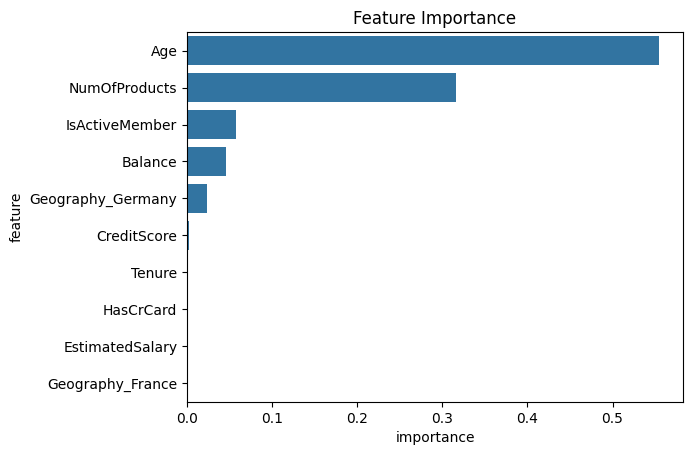

In [52]:
importance_features(X_train, model_cust_7, 10)

In [53]:
model_cust_8 = DecisionTreeClassifier(max_depth = 7, max_leaf_nodes= 2000, random_state=42)
model_cust_8.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",2000
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [54]:
print("Глибина дерева:", model_cust_8.tree_.max_depth)
print("Кількість вузлів дерева:", model_cust_8.tree_.node_count)

Глибина дерева: 7
Кількість вузлів дерева: 199


F1 score on Training: 0.7595
AUROC for Training: 0.9402


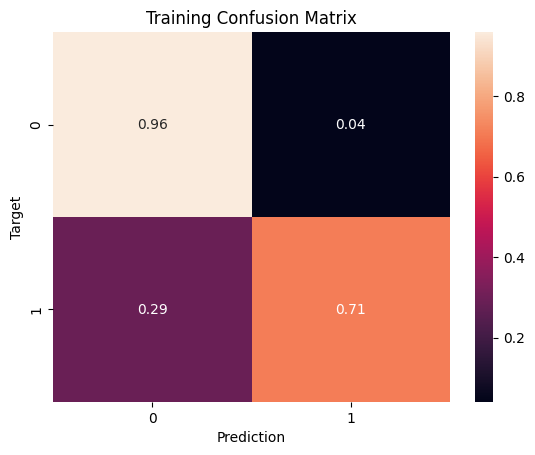

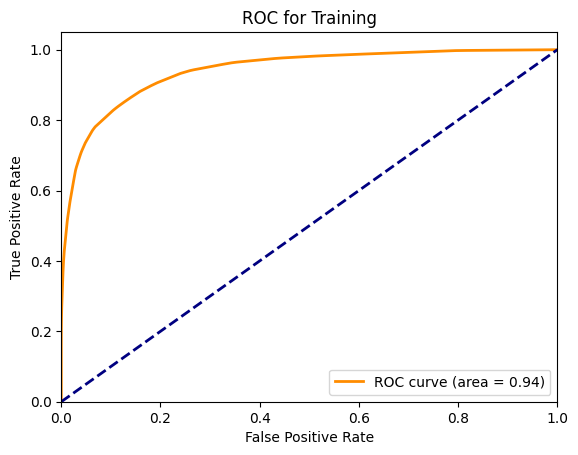

In [55]:
classify_analysis(train_targets, X_train, model_cust_8, 'Training')

F1 score on Validation: 0.714
AUROC for Validation: 0.9173


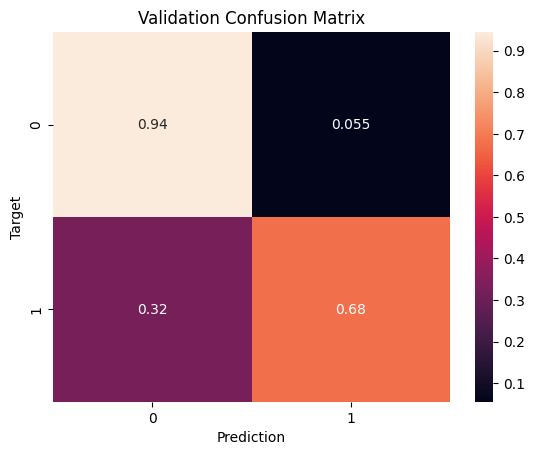

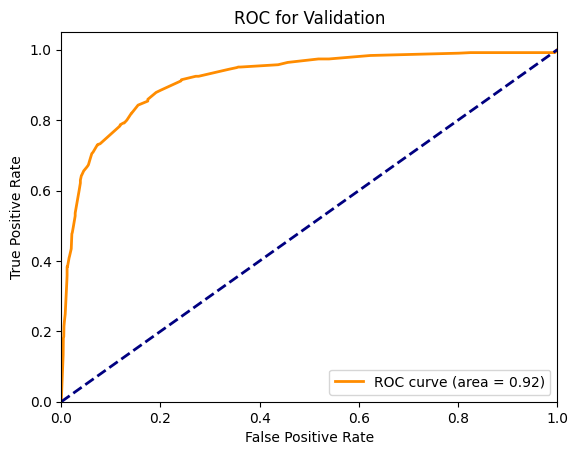

In [56]:
classify_analysis(val_targets, X_val, model_cust_8, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5376
4,NumOfProducts,0.2925
3,Balance,0.0573
6,IsActiveMember,0.0555
9,Geography_Germany,0.0240
0,CreditScore,0.0155
7,EstimatedSalary,0.0115
10,Geography_Spain,0.0031
2,Tenure,0.0020
8,Geography_France,0.0010


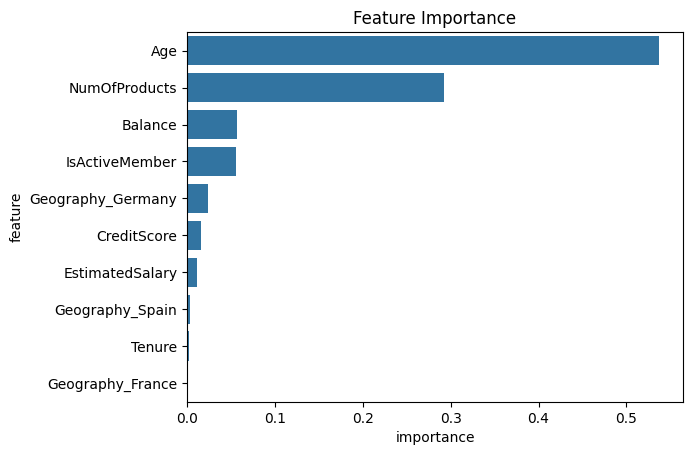

In [57]:
importance_features(X_train, model_cust_8, 10)

In this experiment, models were built taking into account:
- different tree depths
- different number of leaves
- combinations of different depths and leaves.

Overall, the results obtained showed the same or higher value of the area under the ROC curve compared to the base model, except for the case with the maximum number of leaves 1200 (the area is 0.69 at validation). Among the different tree depths, the best results were obtained at depths up to and including 7. Among the different number of leaves, the best results are obtained with a maximum number of leaves of 60.
Regarding combinations of different number of depths and leaves, the best result was obtained with a depth of up to 7 inclusive and a maximum number of leaves of 25.

In general, if we choose one best model, then the most stable and best result was shown by the model with a depth of up to 7 inclusive and a maximum number of leaves of 25. At the same time, this is the only model where the result on both the training and validation data is quite close, the remaining models show signs of overtraining.

It is also interesting that models with a fairly high quality score on the training data highlight the most influential factors Age, NumOfProducts and CreditScore, as the previously considered basic model. While models with better and more stable results in place of CreditScore indicate the significance of Balance and IsActiveMemeber, which is quite important in the practical application of the modeling results.

In [58]:
train_aucroc = []
val_aucroc = []

for i in range(1, 21):
    model = DecisionTreeClassifier(max_depth = i, random_state = 42)
    model.fit(X_train, train_targets)

    train_pred_proba = model.predict_proba(X_train)[:,1]
    val_pred_proba = model.predict_proba(X_val)[:,1]

    train_fpr, train_tpr, train_thresholds = roc_curve(train_targets, train_pred_proba, pos_label = True)
    val_fpr, val_tpr, val_thresholds = roc_curve(val_targets, val_pred_proba, pos_label = True)
   
    roc_auc_train = auc(train_fpr, train_tpr)
    roc_auc_val = auc(val_fpr, val_tpr)

    train_aucroc.append(roc_auc_train)
    val_aucroc.append(roc_auc_val)

result = pd.DataFrame({
    "Max depth": range(1,21),
    "Training AUCROC": train_aucroc,
    "Validation AUCROC": val_aucroc
})

In [59]:
result.style.background_gradient(subset = 'Validation AUCROC', cmap = 'Blues_r')

,Max depth,Training AUCROC,Validation AUCROC
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925172,0.920304
5,6,0.933077,0.921064
6,7,0.940164,0.919289
7,8,0.947650,0.908045
8,9,0.956857,0.874978
9,10,0.965912,0.860835


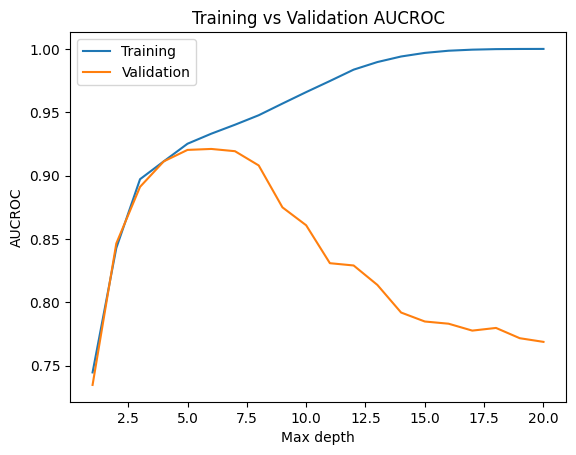

In [60]:
plt.figure()
plt.plot(result['Max depth'], result['Training AUCROC'])
plt.plot(result['Max depth'], result['Validation AUCROC'])
plt.title('Training vs Validation AUCROC')
plt.xlabel('Max depth')
plt.ylabel('AUCROC')
plt.legend(['Training', 'Validation'])
plt.show();

The most stable and best result was obtained when building a model with a depth of 5 inclusive. At the same time, we can notice that at a depth less than or more than 5, the model provides worse results on the validation data. At the same time, at a depth greater than 5, we observe overtraining.

In [61]:
model_depth_5 = DecisionTreeClassifier(max_depth = 5, random_state = 42)
model_depth_5.fit(X_train, train_targets)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [62]:
print("Глибина дерева:", model_depth_5.tree_.max_depth)
print("Кількість вузлів дерева:", model_depth_5.tree_.node_count)

Глибина дерева: 5
Кількість вузлів дерева: 57


F1 score on Training: 0.7009
AUROC for Training: 0.9252


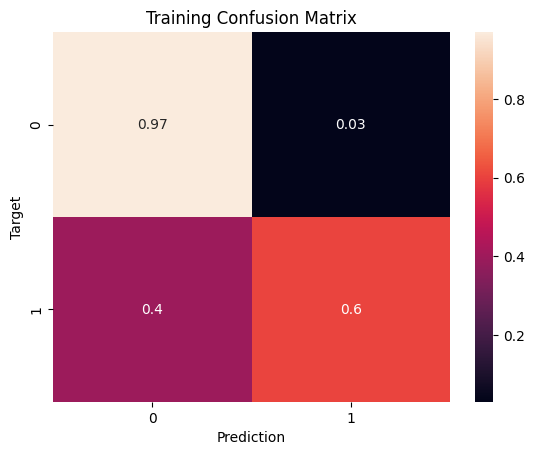

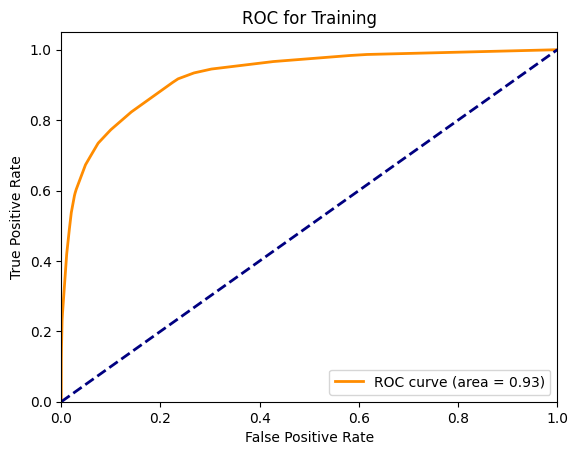

In [63]:
classify_analysis(train_targets, X_train, model_depth_5, 'Training')

F1 score on Validation: 0.6775
AUROC for Validation: 0.9203


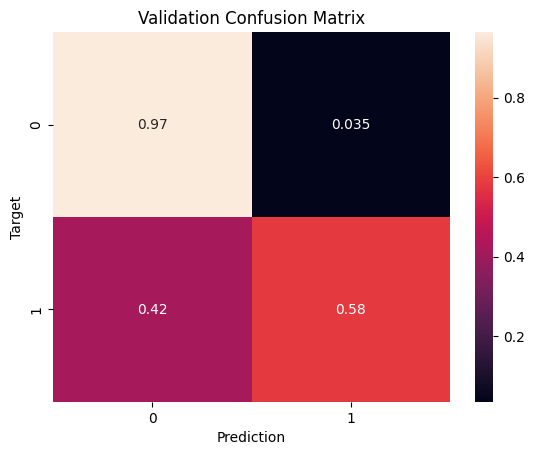

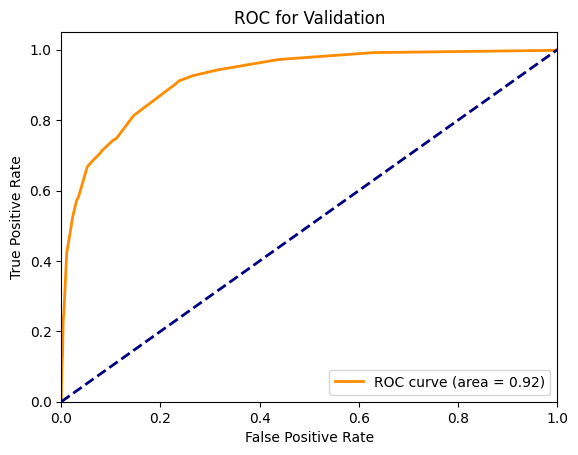

In [64]:
classify_analysis(val_targets, X_val, model_depth_5, 'Validation')

TOP-10 найважливіших ознак


,feature,importance
1,Age,0.5706
4,NumOfProducts,0.3234
6,IsActiveMember,0.0517
3,Balance,0.0299
9,Geography_Germany,0.0236
0,CreditScore,0.0007
7,EstimatedSalary,0.0002
2,Tenure,0.0000
5,HasCrCard,0.0000
8,Geography_France,0.0000


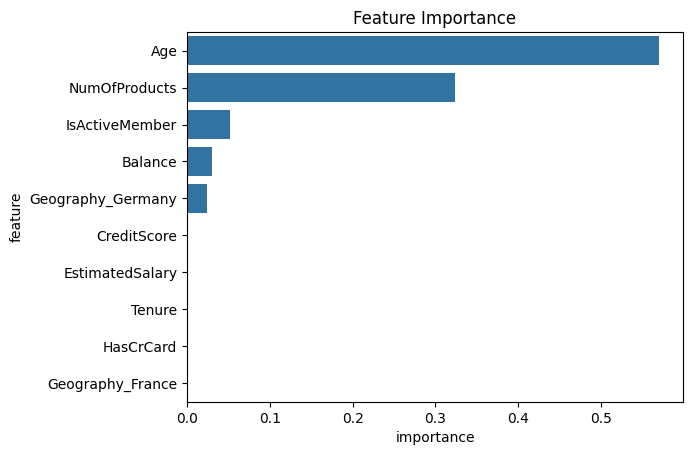

In [65]:
importance_features(X_train, model_depth_5, n=10)

As we can see from the importance of the features, a tree with depth 5 inclusive also highlights IsActiveMember as the third feature, which the base model did not take into account (the third feature was CreditScore).

In [66]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,15000,15594796.0,Chu,584.0,Germany,Male,30.0,2.0,146053.66,1.0,1.0,1.0,157891.86
1,15001,15642821.0,Mazzi,551.0,France,Male,39.0,5.0,0.00,2.0,1.0,1.0,67431.28
2,15002,15716284.0,Onyekachi,706.0,France,Male,43.0,8.0,0.00,2.0,1.0,0.0,156768.45
3,15003,15785078.0,Martin,717.0,Spain,Male,45.0,3.0,0.00,1.0,1.0,1.0,166909.87
4,15004,15662955.0,Kenechukwu,592.0,Spain,Male,43.0,8.0,0.00,2.0,1.0,1.0,143681.97


In [67]:
X_test = preprocess_new_data(test_df, inputs_cols, map_cols, map_codes, encoder_cols, encoder, scaler)

In [68]:
X_test.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
0,-1.034678,-0.944682,-1.087792,1.720173,-1.108193,0.515062,1.016977,0.875226,0.0,1.0,0.0
1,-1.490909,0.161227,-0.009376,-0.717950,0.769304,0.515062,1.016977,-1.109098,1.0,0.0,0.0
2,0.651991,0.652742,1.069040,-0.717950,0.769304,0.515062,-0.983306,0.850584,1.0,0.0,0.0
3,0.804068,0.898500,-0.728320,-0.717950,-1.108193,0.515062,1.016977,1.073044,0.0,0.0,1.0
4,-0.924077,0.652742,1.069040,-0.717950,0.769304,0.515062,1.016977,0.563521,0.0,0.0,1.0


In [69]:
test_df['Exited'] = model_depth_5.predict_proba(X_test)[:,1]

In [70]:
submission = pd.read_csv('sample_submission.csv')

In [71]:
submission['Exited'] = test_df['Exited']

In [72]:
submission.head()

,id,Exited
0,15000,0.237911
1,15001,0.027613
2,15002,0.027613
3,15003,0.770925
4,15004,0.027613


In [73]:
submission.to_csv('submission_log_reg.csv', index = False)